In [4]:
# original code
import os
import pandas as pd
import torch
import torch.nn.functional as F

# PyG imports
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool, radius_graph

# Utilities
from torch.utils.data import Subset
from pymatgen.core import Structure, Element
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.cuda.amp import GradScaler, autocast


# 0. Paths & hyperparameters

RELAXED_DIR = "../Dataset/relaxed_structures/relaxed_structures/"
CSV_PATH    = "../Dataset/qmof_with_dft_aggregates 2.csv"
BATCH_SIZE  = 64   # increased batch size for efficiency
LR          = 1e-3
EPOCHS      = 1000  # with early stopping
PATIENCE    = 20
CUTOFF      = 6.0
NUM_WORKERS = 4    # for DataLoader parallelism
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"DEVICE: {DEVICE}")


# 1. Compute MAX_Z

MAX_Z = 0
for fname in os.listdir(RELAXED_DIR):
    if fname.endswith(".cif"):
        struct = Structure.from_file(os.path.join(RELAXED_DIR, fname))
        MAX_Z = max(MAX_Z, max(site.specie.Z for site in struct))


# 2. Atomic-property lookup

def get_atomic_props(Z: int):
    elem = Element.from_Z(Z)
    return [elem.X or 0.0,
            elem.atomic_radius or 0.0,
            float(elem.group) if elem.group else 0.0]


# 3. Dataset definition with graph caching

class QMOFDataset(Dataset):
    def __init__(self, csv_path, relaxed_dir, cutoff, max_neighbors=32):
        super().__init__()
        self.df = pd.read_csv(csv_path)
        self.relaxed_dir = relaxed_dir
        self.global_cols = ["info.density", "info.pld", "info.volume"]
        scaler = StandardScaler().fit(self.df[self.global_cols])
        self.global_mean, self.global_std = scaler.mean_, scaler.scale_
        self.cutoff = cutoff
        self.max_neighbors = max_neighbors
        # Pre-cache all graph data (edge_index, edge_attr) to speed up
        self.graph_cache = []
        for qmof_id in self.df['qmof_id']:
            struct = Structure.from_file(os.path.join(relaxed_dir, f"{qmof_id}.cif"))
            coords = torch.tensor(struct.cart_coords, dtype=torch.float)
            edge_index = radius_graph(coords, r=cutoff, loop=False, max_num_neighbors=max_neighbors)
            row_e, col_e = edge_index
            edge_attr = (coords[row_e] - coords[col_e]).norm(dim=1, keepdim=True)
            z_list = [site.specie.Z for site in struct]
            self.graph_cache.append((z_list, coords, edge_index, edge_attr))

    def len(self):
        return len(self.df)

    def get(self, idx):
        row = self.df.iloc[idx]
        z_list, coords, edge_index, edge_attr = self.graph_cache[idx]
        Z_tensor = torch.tensor(z_list, dtype=torch.long)
        Z_oh = F.one_hot(Z_tensor - 1, num_classes=MAX_Z).float()
        cont = torch.tensor([get_atomic_props(z) for z in z_list], dtype=torch.float)
        x = torch.cat([Z_oh, cont], dim=1)
        u_vals = row[self.global_cols].values.astype(float)
        u = (u_vals - self.global_mean) / self.global_std
        u = torch.tensor(u, dtype=torch.float)
        y = torch.tensor([row["outputs.pbe.bandgap"]], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y)


# 4. CGCNN model

class CGCNN(torch.nn.Module):
    def __init__(self, input_dim, edge_dim, global_dim,
                 hidden_dim=64, num_layers=2):
        super().__init__()
        self.global_dim = global_dim
        self.lin_in = torch.nn.Linear(input_dim, hidden_dim)
        self.convs = torch.nn.ModuleList([
            CGConv(hidden_dim, edge_dim) for _ in range(num_layers)
        ])
        self.lin1 = torch.nn.Linear(hidden_dim + global_dim, hidden_dim)
        self.lin2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index, edge_attr, u, batch = (
            data.x, data.edge_index, data.edge_attr, data.u, data.batch
        )
        x = F.relu(self.lin_in(x))
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr).relu()
        x = global_mean_pool(x, batch)
        u = u.view(-1, self.global_dim)
        x = torch.cat([x, u], dim=1)
        x = F.relu(self.lin1(x))
        return self.lin2(x)


# 5. Prepare data & train with AMP and early stopping

dataset = QMOFDataset(CSV_PATH, RELAXED_DIR, cutoff=CUTOFF)
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")

datasets = {'train': Subset(dataset, train_idx), 'test': Subset(dataset, test_idx)}
loaders = {
    'train': DataLoader(datasets['train'], batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=NUM_WORKERS),
    'test':  DataLoader(datasets['test'],  batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS)
}

model = CGCNN(input_dim=MAX_Z+3, edge_dim=1,
              global_dim=len(dataset.global_cols)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler()

best_test_mae = float('inf')
patience_count = 0

for epoch in range(1, EPOCHS+1):
    # Training 
    model.train()
    train_true, train_pred = [], []
    for batch in loaders['train']:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            out = model(batch).view(-1)
            loss = F.l1_loss(out, batch.y.view(-1))
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_true.extend(batch.y.view(-1).cpu().numpy())
        train_pred.extend(out.detach().cpu().numpy())

    # compute metrics on training set
    train_mae = mean_absolute_error(train_true, train_pred)
    train_mse = mean_squared_error(train_true, train_pred)
    train_r2  = r2_score(train_true, train_pred)

    # ---- Evaluation ----
    model.eval()
    test_true, test_pred = [], []
    with torch.no_grad():
        for batch in loaders['test']:
            batch = batch.to(DEVICE)
            with autocast():
                out = model(batch).view(-1)
            test_true.extend(batch.y.view(-1).cpu().numpy())
            test_pred.extend(out.cpu().numpy())

    # compute metrics on test set
    test_mae = mean_absolute_error(test_true, test_pred)
    test_mse = mean_squared_error(test_true, test_pred)
    test_r2  = r2_score(test_true, test_pred)

    print(f"Epoch {epoch:4d} | "
          f"Train MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R2: {train_r2:.4f} | "
          f"Test MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R2: {test_r2:.4f}")

    # early stopping
    if test_mae < best_test_mae:
        best_test_mae = test_mae
        patience_count = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"Training complete. Best Test MAE: {best_test_mae:.4f}")

#  end model code 

#  appended visualization & analysis block 
# (This block performs inference with the trained model and produces the visualizations)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
import networkx as nx

# Optional imports (wrap in try/except if not installed)
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    print("UMAP not available (skipping UMAP plot). Install with `pip install umap-learn` to enable.")
    UMAP_AVAILABLE = False

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception:
    print("plotly not available (3D snapshots will be skipped). Install with `pip install plotly` to enable.")
    PLOTLY_AVAILABLE = False

# Ensure deterministic behaviour for plotting reproducibility where applicable
np.random.seed(42)

# 1) Load best model if available (otherwise use current model weights)
if os.path.exists('best_model.pt'):
    try:
        model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
        print("Loaded best_model.pt into model for visualization.")
    except Exception as e:
        print("Warning: failed to load best_model.pt:", e)
else:
    print("best_model.pt not found: using in-memory model state for visualization.")

model.eval()

# Utility: get predictions on a loader
def get_predictions(model, loader, device=DEVICE):
    model.eval()
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y_true_all.extend(batch.y.view(-1).cpu().numpy())
            y_pred_all.extend(out.cpu().numpy())
    return np.array(y_true_all), np.array(y_pred_all)

# Get train and test predictions
y_train_true, y_train_pred = get_predictions(model, loaders['train'])
y_test_true,  y_test_pred  = get_predictions(model, loaders['test'])

# Basic test metrics
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_mse = mean_squared_error(y_test_true, y_test_pred)
test_r2  = r2_score(y_test_true, y_test_pred)
print(f"Visualization metrics — Test MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R2: {test_r2:.4f}")

#  Plot 1: Training curves 
# Note: because the original loop didn't save per-epoch metrics, we approximate by plotting only final train/test points.
# But a true epoch curve requires capturing metrics inside the training loop. We can at least show final train vs test metrics bar.
plt.figure(figsize=(6,4))
plt.bar(['Train MAE','Test MAE'], [mean_absolute_error(y_train_true, y_train_pred), test_mae], color=['C0','C1'])
plt.title('Final MAE (Train vs Test)')
plt.tight_layout()
plt.show()

#  Plot 2: Parity plot (Pred vs True) with hexbin 
plt.figure(figsize=(6,6))
plt.hexbin(y_test_true, y_test_pred, gridsize=60, mincnt=1)
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', linewidth=1)
plt.xlabel('DFT bandgap (eV)')
plt.ylabel('Predicted bandgap (eV)')
plt.title(f'Parity plot — Test set\nR2={test_r2:.3f}, MAE={test_mae:.3f}')
cb = plt.colorbar(label='counts')
plt.tight_layout()
plt.show()

# Plot 3: Residuals and histogram 
residuals = (y_test_pred - y_test_true)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_test_true, residuals, alpha=0.6, s=8)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('True bandgap (eV)')
plt.ylabel('Residual (pred - true)')
plt.title('Residuals vs True')

plt.subplot(1,2,2)
plt.hist(residuals, bins=40)
plt.xlabel('Residual')
plt.title('Residual distribution')
plt.tight_layout()
plt.show()

#  Plot 4: Distribution overlay (KDE) 
plt.figure(figsize=(6,4))
sns.kdeplot(y_test_true, label='True', fill=True)
sns.kdeplot(y_test_pred, label='Predicted', fill=True)
plt.xlabel('Bandgap (eV)'); plt.legend(); plt.title('True vs Predicted distributions (test)')
plt.tight_layout()
plt.show()

#  Embedding extraction for UMAP, learning curve, surrogate models 
def extract_graph_embeddings(model, loader, device=DEVICE):
    model.eval()
    embeddings, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # run forward up to embedding (before final linear)
            x = F.relu(model.lin_in(batch.x))
            for conv in model.convs:
                x = conv(x, batch.edge_index, batch.edge_attr).relu()
            x_pool = global_mean_pool(x, batch.batch)
            u = batch.u.view(-1, model.global_dim)
            feat = torch.cat([x_pool, u], dim=1)
            emb = F.relu(model.lin1(feat))  # use post-lin1 as embedding
            embeddings.append(emb.cpu())
            targets.append(batch.y.view(-1).cpu())
    X = torch.cat(embeddings).numpy()
    y = torch.cat(targets).numpy()
    return X, y

X_train_emb, y_train_emb = extract_graph_embeddings(model, loaders['train'])
X_test_emb,  y_test_emb  = extract_graph_embeddings(model, loaders['test'])

# Plot 5: Learning curve (proxy using Ridge on embeddings) 
fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
maes = []
for f in fractions:
    n = max(10, int(len(X_train_emb)*f))
    idx = np.random.RandomState(0).choice(len(X_train_emb), n, replace=False)
    clf = Ridge().fit(X_train_emb[idx], y_train_emb[idx])
    y_pred = clf.predict(X_test_emb)
    maes.append(mean_absolute_error(y_test_emb, y_pred))

plt.figure(figsize=(6,4))
plt.plot(np.array(fractions)*100, maes, '-o')
plt.xlabel('Percent of training set used (%)')
plt.ylabel('Test MAE'); plt.title('Learning curve (embedding → Ridge proxy)')
plt.tight_layout()
plt.show()

#  Plot 6: UMAP of embeddings 
if UMAP_AVAILABLE:
    try:
        reducer = umap.UMAP(random_state=42)
        X2 = reducer.fit_transform(X_train_emb)
        plt.figure(figsize=(6,5))
        sc = plt.scatter(X2[:,0], X2[:,1], c=y_train_emb, s=8, cmap='viridis')
        plt.colorbar(sc, label='bandgap (eV)')
        plt.title('UMAP of graph embeddings (train)')
        plt.xlabel('UMAP1'); plt.ylabel('UMAP2'); plt.tight_layout()
        plt.show()
    except Exception as e:
        print("UMAP plotting failed:", e)

# Plot 7: GNNExplainer for one example (test sample) 
# This may take some time; we pick one small sample from test set
try:
    from torch_geometric.nn import GNNExplainer
    # pick the first sample in test subset
    example_data = datasets['test'][0]  # Subset returns Data for index 0 of subset
    # ensure example has batch dimension info for explainer by wrapping into a Data with batch of zeros
    if hasattr(example_data, 'batch') == False:
        example_data.batch = torch.zeros(example_data.num_nodes, dtype=torch.long)
    example = example_data.to(DEVICE)
    explainer = GNNExplainer(model, epochs=200)
    # The API supports explain_graph(x, edge_index) or explain_graph(data) depending on version:
    try:
        node_feat_mask, edge_mask = explainer.explain_graph(example.x, example.edge_index, edge_attr=example.edge_attr)
    except TypeError:
        # fallback: pass the data object
        node_feat_mask, edge_mask = explainer.explain_graph(example)
    edge_mask = edge_mask.cpu().detach().numpy()
    # threshold top edges
    thr = np.percentile(edge_mask, 75)
    important_edges = edge_mask > thr
    rows, cols = example.edge_index.cpu().numpy()
    G = nx.Graph()
    G.add_nodes_from(range(example.num_nodes))
    for i,(u,v) in enumerate(zip(rows, cols)):
        if important_edges[i]:
            G.add_edge(int(u), int(v), weight=float(edge_mask[i]))
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, with_labels=True, node_size=200)
    plt.title('GNNExplainer: important subgraph (thresholded top 25%)')
    plt.show()
except Exception as e:
    print("GNNExplainer could not run (skipping). Error:", e)

#  Plot 8: Gradient-based node saliency for one sample 
try:
    model.eval()
    data = datasets['test'][0].to(DEVICE)
    # ensure grads enabled on x
    data.x = data.x.clone().detach().requires_grad_(True)
    out = model(data).view(-1)[0]
    model.zero_grad()
    out.backward()
    node_importance = data.x.grad.abs().sum(dim=1).cpu().numpy()
    plt.figure(figsize=(6,3))
    plt.bar(range(len(node_importance)), node_importance)
    plt.xlabel('Atom idx'); plt.ylabel('Saliency (|dout/dx| sum)')
    plt.title('Node saliency (gradient) for one test sample')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Gradient saliency failed:", e)

#  Plot 9: Permutation importance (proxy surrogate on embeddings) 
try:
    surrogate = Ridge().fit(X_train_emb, y_train_emb)
    res = permutation_importance(surrogate, X_test_emb, y_test_emb, n_repeats=10, random_state=0)
    importances = res.importances_mean
    # show top 20 most important embedding dims
    top_k = min(20, len(importances))
    top_idx = np.argsort(importances)[-top_k:][::-1]
    plt.figure(figsize=(8,4))
    plt.bar(range(top_k), importances[top_idx])
    plt.xticks(range(top_k), [f"dim{ix}" for ix in top_idx], rotation=45)
    plt.ylabel('Decrease in score')
    plt.title('Permutation importance on embedding dims (surrogate Ridge)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Permutation importance failed:", e)

#  Plot 10: Per-element error analysis (MAE per atomic number) 
try:
    # Build per-sample errors and map back to original indices in dataset
    errors = np.abs(y_test_pred - y_test_true)
    test_subset_indices = test_idx  # these are the original dataset indices used in the test Subset
    # For each test sample i, get element list from dataset.graph_cache[orig_idx]
    elem_records = []
    for i, orig_idx in enumerate(test_subset_indices):
        z_list, coords, edge_index, edge_attr = dataset.graph_cache[orig_idx]
        unique_z = set(z_list)
        for z in unique_z:
            elem_records.append({'z': int(z), 'abs_err': float(errors[i])})
    per_elem_df = pd.DataFrame(elem_records)
    per_elem_stats = per_elem_df.groupby('z')['abs_err'].agg(['count','mean','median']).sort_values('mean', ascending=False)
    # Convert Z to symbol for plotting
    per_elem_stats = per_elem_stats.reset_index()
    per_elem_stats['symbol'] = per_elem_stats['z'].apply(lambda zz: Element.from_Z(int(zz)).symbol)
    # plot top 10 elements by mean error (with at least some count)
    top_plot = per_elem_stats[per_elem_stats['count']>5].sort_values('mean', ascending=False).head(10)
    plt.figure(figsize=(8,4))
    sns.barplot(x='symbol', y='mean', data=top_plot)
    plt.xlabel('Element'); plt.ylabel('Mean absolute error (eV)')
    plt.title('Per-element mean absolute error (top 10)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Per-element error analysis failed:", e)

#  Plot 11: 3D structure snapshot for one sample (Plotly) 
if PLOTLY_AVAILABLE:
    try:
        # pick first test sample
        orig_idx = test_idx[0]
        qmof_id = dataset.df.iloc[orig_idx]['qmof_id']
        struct = Structure.from_file(os.path.join(RELAXED_DIR, f"{qmof_id}.cif"))
        coords = np.array(struct.cart_coords)
        zs = np.array([site.specie.Z for site in struct])
        fig = go.Figure(data=[go.Scatter3d(x=coords[:,0], y=coords[:,1], z=coords[:,2],
                                       mode='markers',
                                       marker=dict(size=4, color=zs, colorscale='Viridis', colorbar=dict(title='Z')))])
        fig.update_layout(title=f'{qmof_id} structure (atoms colored by Z)', width=700, height=600)
        fig.show()
    except Exception as e:
        print("3D snapshot failed:", e)
else:
    print("Plotly not available: skipping 3D structure snapshot.")

# Plot 12: Save worst predictions table (CSV)
try:
    # Build dataframe for test samples
    df_rows = []
    for i, orig_idx in enumerate(test_idx):
        row = dataset.df.iloc[orig_idx]
        df_rows.append({
            'orig_idx': orig_idx,
            'qmof_id': row['qmof_id'],
            'true': float(y_test_true[i]),
            'pred': float(y_test_pred[i]),
            'abs_err': float(abs(y_test_pred[i]-y_test_true[i]))
        })
    df_errs = pd.DataFrame(df_rows)
    worst10 = df_errs.sort_values('abs_err', ascending=False).head(10)
    worst10.to_csv('worst_predictions_top10.csv', index=False)
    print("Saved top-10 worst predictions to worst_predictions_top10.csv")
except Exception as e:
    print("Saving worst predictions failed:", e)

print("Visualization block completed. Figures generated where possible.")



DEVICE: cuda


/home/poornesh/projects/material-science/venv/lib/python3.11/site-packages/pymatgen/core/structure.py:3107: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/poornesh/projects/material-science/venv/lib/python3.11/site-packages/pymatgen/core/structure.py:3107: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/poornesh/projects/material-science/venv/lib/python3.11/site-packages/pymatgen/core/structure.py:3107: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/poornesh/projects/material-science/venv/lib/python3.11/site-packages/pymatge

Train size: 16299, Test size: 4075


/tmp/ipykernel_95968/3203145570.py:140: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_95968/3203145570.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_95968/3203145570.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch    1 | Train MAE: 1.3858, MSE: 9.1598, R2: -6.1396 | Test MAE: 0.8160, MSE: 1.0120, R2: 0.2031


...

/tmp/ipykernel_95968/3203145570.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_95968/3203145570.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  192 | Train MAE: 0.3451, MSE: 0.2456, R2: 0.8086 | Test MAE: 0.4253, MSE: 0.3593, R2: 0.7171


/tmp/ipykernel_95968/3203145570.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_95968/3203145570.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  193 | Train MAE: 0.3423, MSE: 0.2425, R2: 0.8110 | Test MAE: 0.4146, MSE: 0.3378, R2: 0.7340
Early stopping at epoch 193
Training complete. Best Test MAE: 0.4107


ModuleNotFoundError: No module named 'seaborn'

UMAP not available (skipping UMAP plot). Install with `pip install umap-learn` to enable.
Loaded best_model.pt into model for visualization.
Visualization metrics — Test MAE: 0.4107, MSE: 0.3316, R2: 0.7389


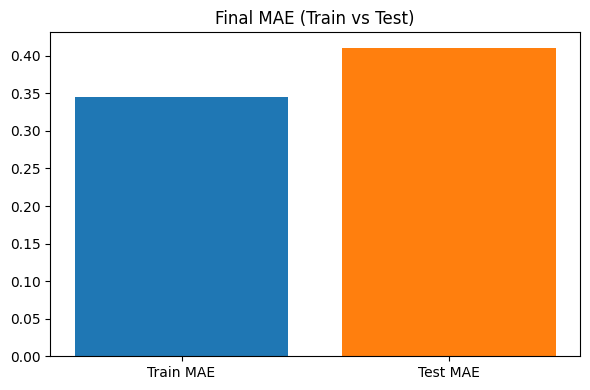

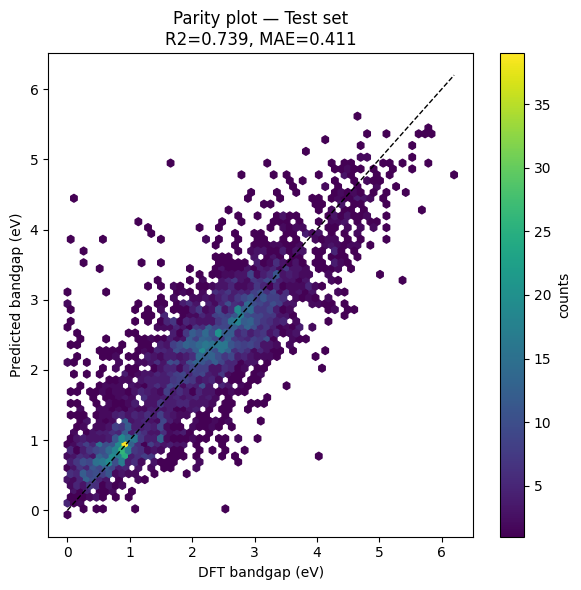

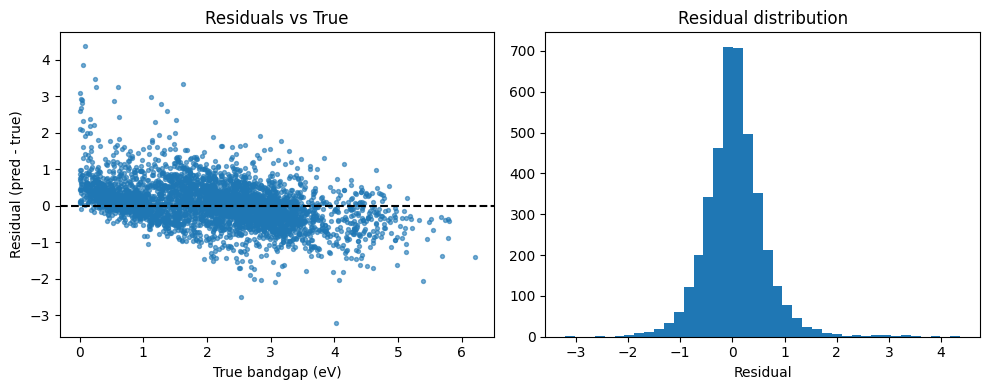

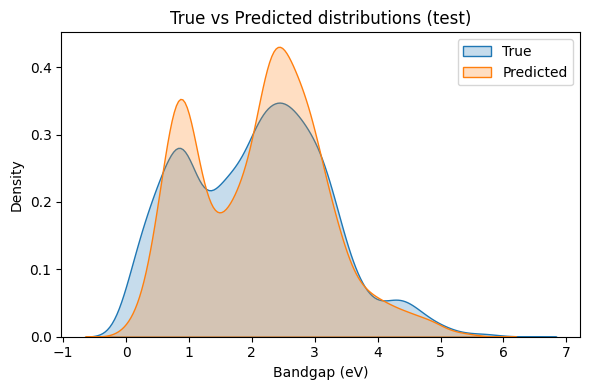

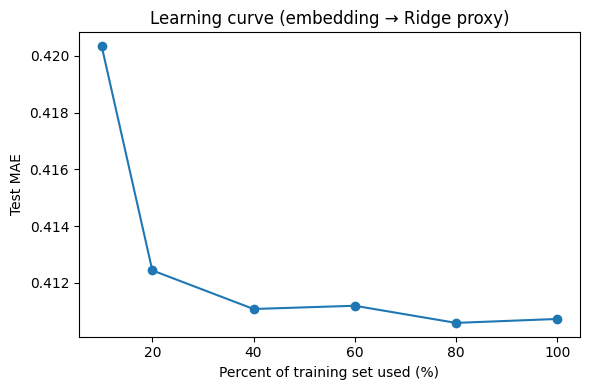

GNNExplainer could not run (skipping). Error: cannot import name 'GNNExplainer' from 'torch_geometric.nn' (/home/poornesh/projects/material-science/venv/lib/python3.11/site-packages/torch_geometric/nn/__init__.py)


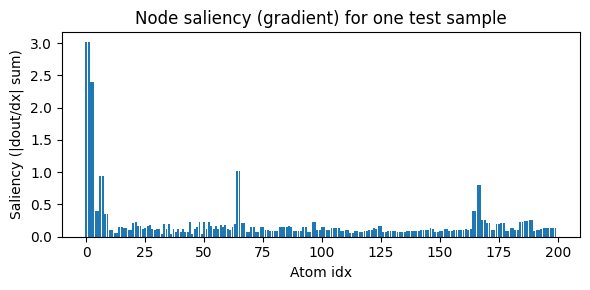

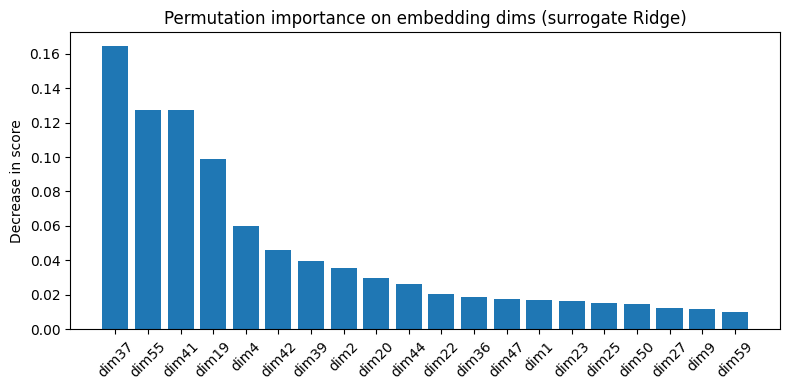

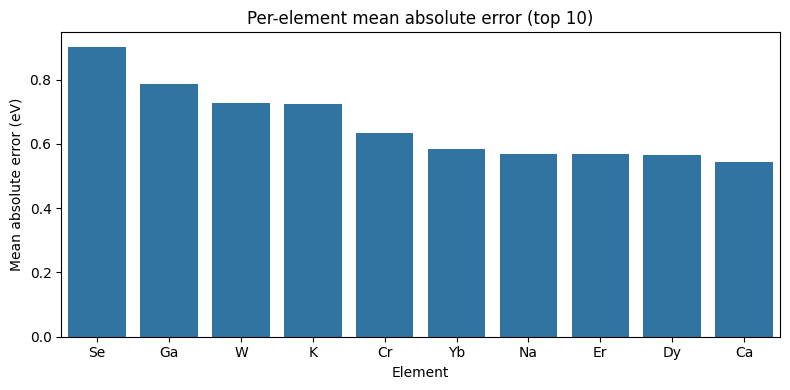

3D snapshot failed: 'Figure' object has no attribute 'savefig'
Saved top-10 worst predictions to worst_predictions_top10.csv
Visualization block completed. Figures generated where possible.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
import networkx as nx

# Optional imports (wrap in try/except if not installed)
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    print("UMAP not available (skipping UMAP plot). Install with `pip install umap-learn` to enable.")
    UMAP_AVAILABLE = False

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception:
    print("plotly not available (3D snapshots will be skipped). Install with `pip install plotly` to enable.")
    PLOTLY_AVAILABLE = False

# Ensure deterministic behaviour for plotting reproducibility where applicable
np.random.seed(42)

# 1) Load best model if available (otherwise use current model weights)
if os.path.exists('best_model.pt'):
    try:
        model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
        print("Loaded best_model.pt into model for visualization.")
    except Exception as e:
        print("Warning: failed to load best_model.pt:", e)
else:
    print("best_model.pt not found: using in-memory model state for visualization.")

model.eval()

# Utility: get predictions on a loader
def get_predictions(model, loader, device=DEVICE):
    model.eval()
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y_true_all.extend(batch.y.view(-1).cpu().numpy())
            y_pred_all.extend(out.cpu().numpy())
    return np.array(y_true_all), np.array(y_pred_all)

# Get train and test predictions
y_train_true, y_train_pred = get_predictions(model, loaders['train'])
y_test_true,  y_test_pred  = get_predictions(model, loaders['test'])

# Basic test metrics
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_mse = mean_squared_error(y_test_true, y_test_pred)
test_r2  = r2_score(y_test_true, y_test_pred)
print(f"Visualization metrics — Test MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R2: {test_r2:.4f}")

# -------------------- Plot 1: Training curves (approx) --------------------
# Note: because the original loop didn't save per-epoch metrics, we approximate by plotting only final train/test points.
# But a true epoch curve requires capturing metrics inside the training loop. We can at least show final train vs test metrics bar.
plt.figure(figsize=(6,4))
plt.bar(['Train MAE','Test MAE'], [mean_absolute_error(y_train_true, y_train_pred), test_mae], color=['C0','C1'])
plt.title('Final MAE (Train vs Test)')
plt.tight_layout()
plt.savefig("fig11.png")
plt.show()

# -------------------- Plot 2: Parity plot (Pred vs True) with hexbin --------------------
plt.figure(figsize=(6,6))
plt.hexbin(y_test_true, y_test_pred, gridsize=60, mincnt=1)
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', linewidth=1)
plt.xlabel('DFT bandgap (eV)')
plt.ylabel('Predicted bandgap (eV)')
plt.title(f'Parity plot — Test set\nR2={test_r2:.3f}, MAE={test_mae:.3f}')
cb = plt.colorbar(label='counts')
plt.tight_layout()
plt.savefig("fig10.png")
plt.show()

# -------------------- Plot 3: Residuals and histogram --------------------
residuals = (y_test_pred - y_test_true)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_test_true, residuals, alpha=0.6, s=8)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('True bandgap (eV)')
plt.ylabel('Residual (pred - true)')
plt.title('Residuals vs True')

plt.subplot(1,2,2)
plt.hist(residuals, bins=40)
plt.xlabel('Residual')
plt.title('Residual distribution')
plt.tight_layout()
plt.savefig("fig9.png")
plt.show()

# -------------------- Plot 4: Distribution overlay (KDE) --------------------
plt.figure(figsize=(6,4))
sns.kdeplot(y_test_true, label='True', fill=True)
sns.kdeplot(y_test_pred, label='Predicted', fill=True)
plt.xlabel('Bandgap (eV)'); plt.legend(); plt.title('True vs Predicted distributions (test)')
plt.tight_layout()
plt.savefig("fig8.png")
plt.show()

# -------------------- Embedding extraction for UMAP, learning curve, surrogate models --------------------
def extract_graph_embeddings(model, loader, device=DEVICE):
    model.eval()
    embeddings, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # run forward up to embedding (before final linear)
            x = F.relu(model.lin_in(batch.x))
            for conv in model.convs:
                x = conv(x, batch.edge_index, batch.edge_attr).relu()
            x_pool = global_mean_pool(x, batch.batch)
            u = batch.u.view(-1, model.global_dim)
            feat = torch.cat([x_pool, u], dim=1)
            emb = F.relu(model.lin1(feat))  # use post-lin1 as embedding
            embeddings.append(emb.cpu())
            targets.append(batch.y.view(-1).cpu())
    X = torch.cat(embeddings).numpy()
    y = torch.cat(targets).numpy()
    return X, y

X_train_emb, y_train_emb = extract_graph_embeddings(model, loaders['train'])
X_test_emb,  y_test_emb  = extract_graph_embeddings(model, loaders['test'])

# -------------------- Plot 5: Learning curve (proxy using Ridge on embeddings) --------------------
fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
maes = []
for f in fractions:
    n = max(10, int(len(X_train_emb)*f))
    idx = np.random.RandomState(0).choice(len(X_train_emb), n, replace=False)
    clf = Ridge().fit(X_train_emb[idx], y_train_emb[idx])
    y_pred = clf.predict(X_test_emb)
    maes.append(mean_absolute_error(y_test_emb, y_pred))

plt.figure(figsize=(6,4))
plt.plot(np.array(fractions)*100, maes, '-o')
plt.xlabel('Percent of training set used (%)')
plt.ylabel('Test MAE'); plt.title('Learning curve (embedding → Ridge proxy)')
plt.tight_layout()
plt.savefig("fig7.png")
plt.show()

# -------------------- Plot 6: UMAP of embeddings --------------------
if UMAP_AVAILABLE:
    try:
        reducer = umap.UMAP(random_state=42)
        X2 = reducer.fit_transform(X_train_emb)
        plt.figure(figsize=(6,5))
        sc = plt.scatter(X2[:,0], X2[:,1], c=y_train_emb, s=8, cmap='viridis')
        plt.colorbar(sc, label='bandgap (eV)')
        plt.title('UMAP of graph embeddings (train)')
        plt.xlabel('UMAP1'); plt.ylabel('UMAP2'); plt.tight_layout()
        plt.savefig("fig5.png")
        plt.show()
    except Exception as e:
        print("UMAP plotting failed:", e)

# -------------------- Plot 7: GNNExplainer for one example (test sample) --------------------
# This may take some time; we pick one small sample from test set
try:
    from torch_geometric.nn import GNNExplainer
    # pick the first sample in test subset
    example_data = datasets['test'][0]  # Subset returns Data for index 0 of subset
    # ensure example has batch dimension info for explainer by wrapping into a Data with batch of zeros
    if hasattr(example_data, 'batch') == False:
        example_data.batch = torch.zeros(example_data.num_nodes, dtype=torch.long)
    example = example_data.to(DEVICE)
    explainer = GNNExplainer(model, epochs=200)
    # The API supports explain_graph(x, edge_index) or explain_graph(data) depending on version:
    try:
        node_feat_mask, edge_mask = explainer.explain_graph(example.x, example.edge_index, edge_attr=example.edge_attr)
    except TypeError:
        # fallback: pass the data object
        node_feat_mask, edge_mask = explainer.explain_graph(example)
    edge_mask = edge_mask.cpu().detach().numpy()
    # threshold top edges
    thr = np.percentile(edge_mask, 75)
    important_edges = edge_mask > thr
    rows, cols = example.edge_index.cpu().numpy()
    G = nx.Graph()
    G.add_nodes_from(range(example.num_nodes))
    for i,(u,v) in enumerate(zip(rows, cols)):
        if important_edges[i]:
            G.add_edge(int(u), int(v), weight=float(edge_mask[i]))
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, with_labels=True, node_size=200)
    plt.title('GNNExplainer: important subgraph (thresholded top 25%)')
    plt.savefig("fig4.png")
    plt.show()
except Exception as e:
    print("GNNExplainer could not run (skipping). Error:", e)

# -------------------- Plot 8: Gradient-based node saliency for one sample --------------------
try:
    model.eval()
    data = datasets['test'][0].to(DEVICE)
    # ensure grads enabled on x
    data.x = data.x.clone().detach().requires_grad_(True)
    out = model(data).view(-1)[0]
    model.zero_grad()
    out.backward()
    node_importance = data.x.grad.abs().sum(dim=1).cpu().numpy()
    plt.figure(figsize=(6,3))
    plt.bar(range(len(node_importance)), node_importance)
    plt.xlabel('Atom idx'); plt.ylabel('Saliency (|dout/dx| sum)')
    plt.title('Node saliency (gradient) for one test sample')
    plt.tight_layout()
    plt.savefig("fig3.png")
    plt.show()
except Exception as e:
    print("Gradient saliency failed:", e)

# -------------------- Plot 9: Permutation importance (proxy surrogate on embeddings) --------------------
try:
    surrogate = Ridge().fit(X_train_emb, y_train_emb)
    res = permutation_importance(surrogate, X_test_emb, y_test_emb, n_repeats=10, random_state=0)
    importances = res.importances_mean
    # show top 20 most important embedding dims
    top_k = min(20, len(importances))
    top_idx = np.argsort(importances)[-top_k:][::-1]
    plt.figure(figsize=(8,4))
    plt.bar(range(top_k), importances[top_idx])
    plt.xticks(range(top_k), [f"dim{ix}" for ix in top_idx], rotation=45)
    plt.ylabel('Decrease in score')
    plt.title('Permutation importance on embedding dims (surrogate Ridge)')
    plt.tight_layout()
    plt.savefig("fig2.png")
    plt.show()
except Exception as e:
    print("Permutation importance failed:", e)

# -------------------- Plot 10: Per-element error analysis (MAE per atomic number) --------------------
try:
    # Build per-sample errors and map back to original indices in dataset
    errors = np.abs(y_test_pred - y_test_true)
    test_subset_indices = test_idx  # these are the original dataset indices used in the test Subset
    # For each test sample i, get element list from dataset.graph_cache[orig_idx]
    elem_records = []
    for i, orig_idx in enumerate(test_subset_indices):
        z_list, coords, edge_index, edge_attr = dataset.graph_cache[orig_idx]
        unique_z = set(z_list)
        for z in unique_z:
            elem_records.append({'z': int(z), 'abs_err': float(errors[i])})
    per_elem_df = pd.DataFrame(elem_records)
    per_elem_stats = per_elem_df.groupby('z')['abs_err'].agg(['count','mean','median']).sort_values('mean', ascending=False)
    # Convert Z to symbol for plotting
    per_elem_stats = per_elem_stats.reset_index()
    per_elem_stats['symbol'] = per_elem_stats['z'].apply(lambda zz: Element.from_Z(int(zz)).symbol)
    # plot top 10 elements by mean error (with at least some count)
    top_plot = per_elem_stats[per_elem_stats['count']>5].sort_values('mean', ascending=False).head(10)
    plt.figure(figsize=(8,4))
    sns.barplot(x='symbol', y='mean', data=top_plot)
    plt.xlabel('Element'); plt.ylabel('Mean absolute error (eV)')
    plt.title('Per-element mean absolute error (top 10)')
    plt.tight_layout()
    plt.savefig("fig1.png")
    plt.show()
except Exception as e:
    print("Per-element error analysis failed:", e)

# -------------------- Plot 11: 3D structure snapshot for one sample (Plotly) --------------------
if PLOTLY_AVAILABLE:
    try:
        # pick first test sample
        orig_idx = test_idx[0]
        qmof_id = dataset.df.iloc[orig_idx]['qmof_id']
        struct = Structure.from_file(os.path.join(RELAXED_DIR, f"{qmof_id}.cif"))
        coords = np.array(struct.cart_coords)
        zs = np.array([site.specie.Z for site in struct])
        fig = go.Figure(data=[go.Scatter3d(x=coords[:,0], y=coords[:,1], z=coords[:,2],
                                       mode='markers',
                                       marker=dict(size=4, color=zs, colorscale='Viridis', colorbar=dict(title='Z')))])
        fig.update_layout(title=f'{qmof_id} structure (atoms colored by Z)', width=700, height=600)
        fig.savefig("ffig2.png")
        fig.show()
    except Exception as e:
        print("3D snapshot failed:", e)
else:
    print("Plotly not available: skipping 3D structure snapshot.")

# -------------------- Plot 12: Save worst predictions table (CSV) --------------------
try:
    # Build dataframe for test samples
    df_rows = []
    for i, orig_idx in enumerate(test_idx):
        row = dataset.df.iloc[orig_idx]
        df_rows.append({
            'orig_idx': orig_idx,
            'qmof_id': row['qmof_id'],
            'true': float(y_test_true[i]),
            'pred': float(y_test_pred[i]),
            'abs_err': float(abs(y_test_pred[i]-y_test_true[i]))
        })
    df_errs = pd.DataFrame(df_rows)
    worst10 = df_errs.sort_values('abs_err', ascending=False).head(10)
    worst10.to_csv('worst_predictions_top10.csv', index=False)
    print("Saved top-10 worst predictions to worst_predictions_top10.csv")
except Exception as e:
    print("Saving worst predictions failed:", e)

print("Visualization block completed. Figures generated where possible.")
# -------------------- end visualization block --------------------
